In [1]:
import numpy as np
import cmath
import math
import sympy as sp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

### Oefening 45
a) Teken $f(x) = e^{2x+1}$ samen met zijn 2 afgekapte Taylorontwikkelingen rond $x = 1$, resp. na de term in $x$ en na de term in $x^2$.

b) Herhaal deze tekening voor $f(x) = x^2 - x$. Leg het resultaat uit.

Taylorontwikkeling rond x=1 na de term in x (met 'restterm):  exp(3) + 2*(x - 1)*exp(3) + O((x - 1)**2, (x, 1))
Taylorontwikkeling rond x=1 na de term in x:  2*(x - 1)*exp(3) + exp(3)
Taylorontwikkeling rond x=1 na de term in x²:  2*(x - 1)**2*exp(3) + 2*(x - 1)*exp(3) + exp(3)


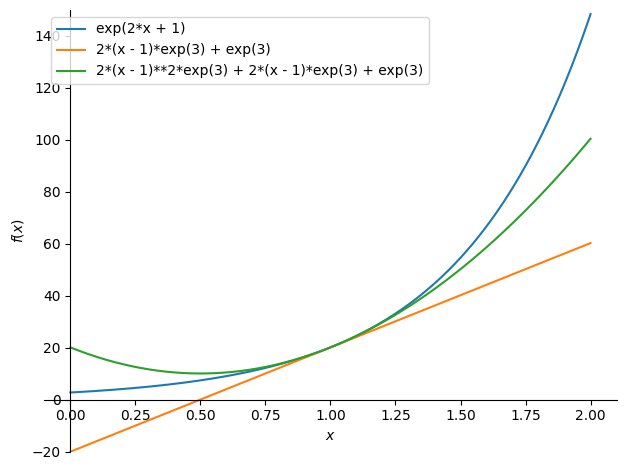

In [2]:
x= sp.symbols('x')
f = sp.exp(2*x+1)

taylor1 = f.series(x,1,2) # graad 1
print("Taylorontwikkeling rond x=1 na de term in x (met 'restterm): ", taylor1)
print("Taylorontwikkeling rond x=1 na de term in x: ", taylor1.removeO())
taylor2=f.series(x,1,3) #graad 2
print("Taylorontwikkeling rond x=1 na de term in x²: ", taylor2.removeO())

sp.plot(f,taylor1.removeO(),taylor2.removeO(), (x,0,2), legend = True, ylim=(-20,150))

Taylorontwikkeling rond x=1 na de term in x (met 'restterm):  -1 + x + O((x - 1)**2, (x, 1))
Taylorontwikkeling rond x=1 na de term in x:  x - 1
Taylorontwikkeling rond x=1 na de term in x²:  x + (x - 1)**2 - 1


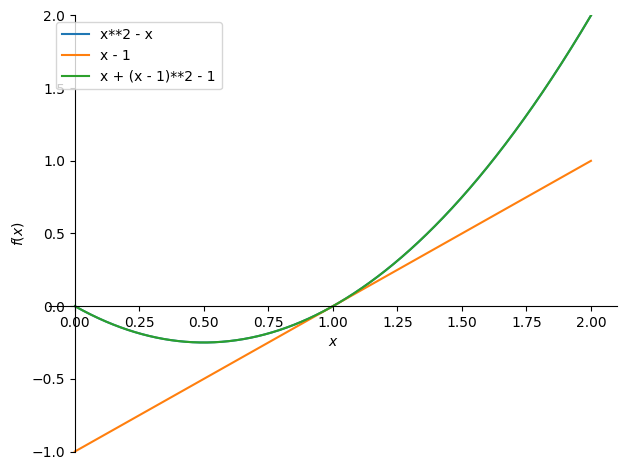

In [3]:
x = sp.symbols('x')
f = x**2 - x

taylor1 = f.series(x,1,2) # graad 1
print("Taylorontwikkeling rond x=1 na de term in x (met 'restterm): ", taylor1)
print("Taylorontwikkeling rond x=1 na de term in x: ", taylor1.removeO())
taylor2=f.series(x,1,3) #graad 2
print("Taylorontwikkeling rond x=1 na de term in x²: ", taylor2.removeO())

sp.plot(f,taylor1.removeO(),taylor2.removeO(), (x,0,2), legend = True, ylim=(-1,2))

### Oefening 46
Bepaal het inverse Laplacebeeld van $F(s) = \frac{2s^3 + 8s^2 + 12s + 32}{s^4 + 4s^3 + 8s^2 + 16s + 16}$.

In [4]:
t,s=sp.symbols('t s')
F=(2*s**3+8*s**2+12*s+32)/(s**4+4*s**3+8*s**2+16*s+16)
f=sp.inverse_laplace_transform(F,s,t)
print("Het invers laplacebeeld: f = ",f)

Het invers laplacebeeld: f =  3*t*exp(-2*t)*Heaviside(t) + sin(2*t)*Heaviside(t)/2 + 2*exp(-2*t)*Heaviside(t)


### Oefening 48
Bereken het Laplacebeeld van de functie die niet nul is tussen $1$ en $2$ en daar als functiewaarde $2 - t$ aanneemt.Bereken van het resultaat het inverse Laplacebeeld en maak een tekening van de functie.

Controle: plot van de functie f


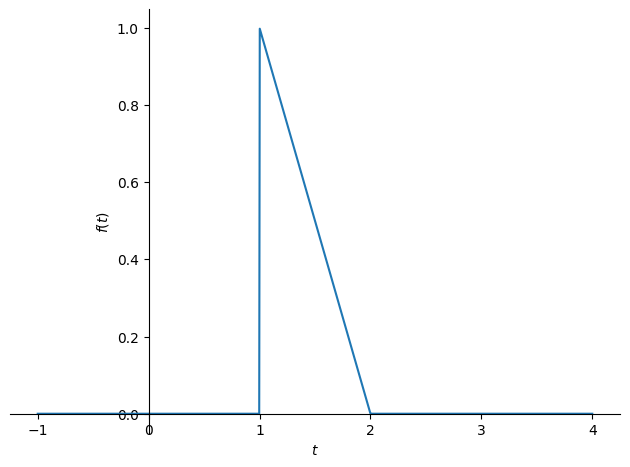

In [5]:
t,s=sp.symbols('t s')
f=(2-t)*sp.Heaviside(t-1)+(t-2)*sp.Heaviside(t-2)
print("Controle: plot van de functie f")
sp.plotting.plot(f,(t,-1,4))

We berekenen het Laplacebeeld van f:
F =  ((1/s - 1/s**2)*exp(-s) + exp(-2*s)/s**2, 0, True)
We berekenen het invers Laplacebeeld van F:
I =  (t - 2)*Heaviside(t - 2) - (t - 1)*Heaviside(t - 1) + Heaviside(t - 1)
We krijgen terug de functie f waarvan we vertrokken.
Controle: plot van de functie I


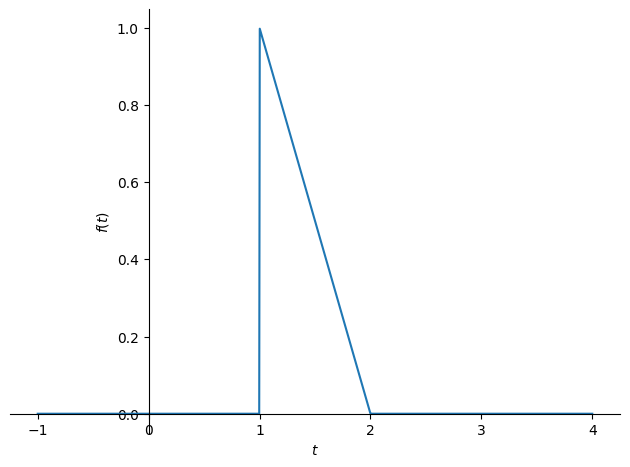

In [6]:
print("We berekenen het Laplacebeeld van f:")
F=sp.laplace_transform(f,t,s)
print("F = ",F)
print("We berekenen het invers Laplacebeeld van F:")
I=sp.inverse_laplace_transform(F[0],s,t)
print("I = ",I)
print("We krijgen terug de functie f waarvan we vertrokken.")
print("Controle: plot van de functie I")
sp.plotting.plot(I,(t,-1,4))

### Oefening 51
Bepaal alle waarden van $a$ zodat $|A| = -1$ met $A = \begin{pmatrix} 1 & a & 0 & 6 \\ 4 & 0 & 1 & 2 \\ 1 & 3 & -1 & 6 \\ 1 & 10 & 3 & 11 \end{pmatrix}$.

In [7]:
a = sp.symbols('a')
A=sp.Matrix([[1,a,0,6],
             [4,0,1,2],
             [1,3,-1,6],
             [1,10,3,11]])
detA=A.det()
vgl=sp.Eq(detA,-1)
opl = sp.solve(vgl,a)
print('a = ',opl)

a =  [432/113]


### Oefening 52
Een oefening uit de cursus elektriciteit geeft aanleiding tot volgend stelsel:$$\begin{cases} 
i_2 - i_1 - i_3 = 0 \\ 
i_3 - i_4 - i_5 = 0 \\ 
30i_1 + 30i_2 = -60 \\ 
30i_2 + 15i_3 + 30i_5 = 60 \\ 
-30i_5 + 10i_4 = 200 
\end{cases}$$Bepaal de stroomsterkten.

In [8]:
A=np.array(([[-1,1,-1,0,0],
             [0,0,1,-1,-1],
             [30,30,0,0,0],
             [0,30,15,0,30],
             [0,0,0,10,-30]]))
b=np.array(([0,0,-60,60,200]))
I=np.linalg.solve(A,b)
print("I = ", I)

I =  [-4.2  2.2  6.4  9.8 -3.4]


### Oefening 55
Bepaal een orthonormaal stel eigenvectoren van de lineaire transformatie $g : (x, y, z) \rightarrow (-x, -y, -z)$.Wat is de fysische interpretatie hiervan? Verklaar het resultaat.

In [9]:
A=np.array([[-1,0,0],
            [0,-1,0],
            [0,0,-1]])
eigenwaarden,eigenvectoren=np.linalg.eig(A)
print("Eigenwaarden van A",eigenwaarden)
print("Eigenvectoren van A",eigenvectoren)

Eigenwaarden van A [-1. -1. -1.]
Eigenvectoren van A [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
